In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [11]:
df = pd.read_csv("../Base_Datos/df_final.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   float64
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeNumber            1470 non-null   int64  
 9   EnvironmentSatisfaction   1470 non-null   int64  
 10  Gender                    1470 non-null   object 
 11  HourlyRate                1470 non-null   int64  
 12  JobInvolvement            1470 non-null   int64  
 13  JobLevel                  1470 non-null   int64  
 14  JobRole 

In [ ]:

# Métricas por género
rotacion_genero = df.groupby('Gender')['Attrition_flag'].mean()
satisf_genero = df.groupby('Gender')['JobSatisfaction'].mean()
rotacion_genero_depto = df.groupby(['Gender','Department'])['Attrition_flag'].mean()

print("Tasa de rotación por género:\n", rotacion_genero, "\n")
print("JobSatisfaction media por género:\n", satisf_genero, "\n")
print("Tasa de rotación por género y departamento:\n", rotacion_genero_depto, "\n")



Tasa de rotación por género:
 Gender
Female    0.147959
Male      0.170068
Name: Attrition_flag, dtype: float64 

JobSatisfaction media por género:
 Gender
Female    2.687075
Male      2.770975
Name: JobSatisfaction, dtype: float64 

Tasa de rotación por género y departamento:
 Gender  Department            
Female  Human Resources           0.300000
        Research & Development    0.110215
        Sales                     0.202128
        Unknown                   0.250000
Male    Human Resources           0.139535
        Research & Development    0.149912
        Sales                     0.203187
        Unknown                   0.380952
Name: Attrition_flag, dtype: float64 



A nivel global, la tasa de rotación es algo más elevada en los hombres (17,0%) que en las mujeres (14,8%). Esto indica que, en términos de fuga de talento, la compañía pierde algo más de presencia masculina que femenina, aunque la diferencia no es extrema.

#Satisfacción media por género
JobSatisfaction media mujeres: 2.69.
JobSatisfaction media hombres: 2.77.

Cuando analizamos la satisfacción laboral media, vemos que los hombres presentan una puntuación ligeramente superior (2,77) frente a las mujeres (2,69). La diferencia es modesta, por lo que no se aprecia una brecha clara de satisfacción entre géneros a nivel agregado.

#Rotación por género y departamento
Human Resources: mujeres 30%, hombres 14%.
Research & Development: mujeres 11%, hombres 15%.
Sales: mujeres 20,2%, hombres 20,3% (prácticamente igual).
Unknown: mujeres 25%, hombres 38,1%

Al desagregar la rotación por género y departamento aparecen matices importantes. En Human Resources, la tasa de salida de las mujeres (30%) duplica con creces la de los hombres (14%), lo que sugiere que, en este entorno concreto, las profesionales están abandonando la compañía con mucha más frecuencia. En cambio, en Research & Development la situación se invierte ligeramente: la rotación femenina (11%) es algo menor que la masculina (15%). En el área comercial (Sales) las tasas son prácticamente idénticas para ambos géneros, lo que indica que la presión del rol afecta de forma similar a hombres y mujeres. Finalmente, en el grupo con departamento Unknown la rotación es especialmente alta entre los hombres (38%), aunque se trata de un colectivo pequeño que habría que interpretar con cautela.

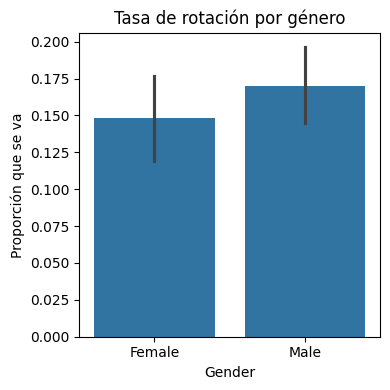

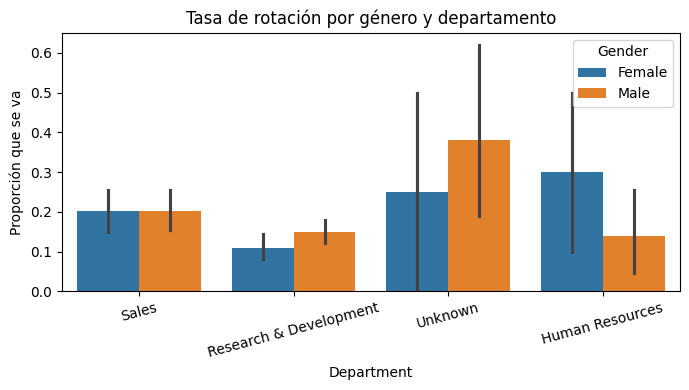

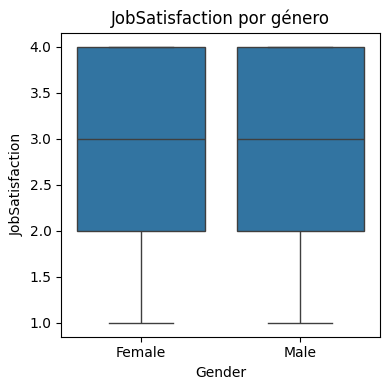

In [13]:
# Rotación por género
plt.figure(figsize=(4,4))
sns.barplot(data=df, x='Gender', y='Attrition_flag', estimator='mean')
plt.title('Tasa de rotación por género')
plt.ylabel('Proporción que se va')
plt.tight_layout()
plt.show()

# Rotación por género y departamento
plt.figure(figsize=(7,4))
sns.barplot(
    data=df,
    x='Department',
    y='Attrition_flag',
    hue='Gender',
    estimator='mean'
)
plt.title('Tasa de rotación por género y departamento')
plt.ylabel('Proporción que se va')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Satisfacción por género
plt.figure(figsize=(4,4))
sns.boxplot(data=df, x='Gender', y='JobSatisfaction')
plt.title('JobSatisfaction por género')
plt.tight_layout()
plt.show()


In [14]:
# Salario medio global por género
df.groupby('Gender')['MonthlyIncome'].mean()

# Salario por género y nivel jerárquico
df.groupby(['Gender','JobLevel'])['MonthlyIncome'].mean()

# Salario por género y rol
df.groupby(['Gender','JobRole'])['MonthlyIncome'].mean()


Gender  JobRole                  
Female  Healthcare Representative     7233.549020
        Human Resources               4540.687500
        Laboratory Technician         3246.905882
        Manager                      16595.723404
        Manufacturing Director        7407.833333
        Research Director            15144.484848
        Research Scientist            3344.473684
        Sales Executive               6734.901515
        Sales Representative          2774.947368
Male    Healthcare Representative     7568.312500
        Human Resources               3956.944444
        Laboratory Technician         3227.224138
        Manager                      17409.327273
        Manufacturing Director        7182.671233
        Research Director            16657.787234
        Research Scientist            3198.376404
        Sales Executive               7033.118557
        Sales Representative          2587.200000
Name: MonthlyIncome, dtype: float64

#Salario medio por género y rol
En Healthcare Representative, los hombres cobran algo más que las mujeres (7568 vs 7234).

En Manager y Research Director, los hombres también tienen un salario medio superior (17409 vs 16596 en Manager; 16658 vs 15144 en Research Director).

En cambio, en Human Resources y Manufacturing Director las mujeres cobran más que los hombres (4541 vs 3957 en HR; 7408 vs 7183 en Manufacturing Director).
​
En Laboratory Technician, Research Scientist, Sales Executive y Sales Representative, las diferencias son pequeñas y no apuntan a una única dirección clara.

Cuando comparamos el salario medio por género dentro de cada rol (JobRole), encontramos un patrón mixto. En posiciones de mayor responsabilidad como Manager o Research Director, los hombres presentan salarios medios superiores a los de las mujeres, lo que sugiere una posible brecha salarial en la parte alta de la pirámide. Sin embargo, en otros puestos como Human Resources o Manufacturing Director ocurre lo contrario: las mujeres perciben una retribución media algo mayor. En roles más técnicos u operativos (Laboratory Technician, Research Scientist, Sales Executive y Sales Representative) las diferencias son reducidas, sin una dirección clara a favor de uno u otro género. En conjunto, esto apunta a que la brecha de género en retribución no es uniforme, sino que depende del tipo de puesto y del nivel de responsabilidad.


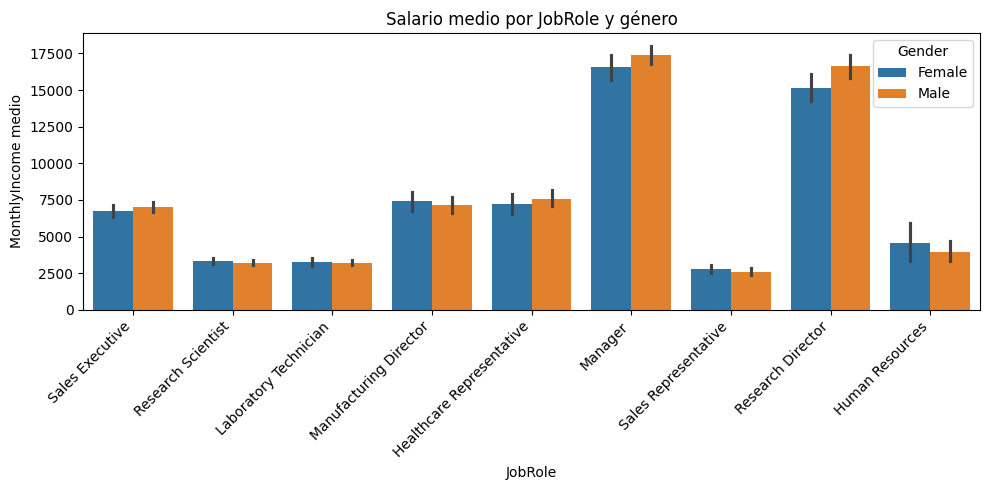

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='JobRole',
    y='MonthlyIncome',
    hue='Gender',
    estimator='mean'
)
plt.title('Salario medio por JobRole y género')
plt.xlabel('JobRole')
plt.ylabel('MonthlyIncome medio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [17]:
# Distribución de niveles jerárquicos por género (porcentajes)
dist_level_genero = (
    df.groupby(['Gender','JobLevel'])['EmployeeNumber']
      .count()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
)
print(dist_level_genero)

# Experiencia media total por género
print("\nTotalWorkingYears medio por género:")
print(df.groupby('Gender')['TotalWorkingYears'].mean())


Gender  Gender  JobLevel
Female  Female  1           0.338435
                2           0.374150
                3           0.159864
                4           0.086735
                5           0.040816
Male    Male    1           0.390023
                2           0.356009
                3           0.140590
                4           0.062358
                5           0.051020
Name: EmployeeNumber, dtype: float64

TotalWorkingYears medio por género:
Gender
Female    11.726190
Male      10.981859
Name: TotalWorkingYears, dtype: float64


Posiciones más/menos cualificadas (JobLevel)
Mujeres:
Nivel 1: 33,8%
Nivel 2: 37,4%
Niveles 3–5: 28,4% en total.
​
Hombres:
Nivel 1: 39,0%
Nivel 2: 35,6%
Niveles 3–5: 25,4% en total

Las mujeres están ligeramente menos concentradas en el nivel 1 y algo más presentes en los niveles intermedios y altos (3–4) que los hombres, aunque la diferencia es pequeña.

Al analizar la distribución de niveles jerárquicos (JobLevel) por género, no observamos una infrarrepresentación clara de las mujeres en los puestos más cualificados. Aproximadamente un 33,8% de las mujeres se sitúa en el nivel 1 frente al 39,0% de los hombres, mientras que los niveles 3–5 concentran un 28,4% de mujeres frente a un 25,4% de hombres. Es decir, en este dataset las mujeres no parecen quedar relegadas de forma sistemática a los niveles más bajos; incluso tienen una presencia ligeramente mayor en los niveles intermedios y altos, aunque las diferencias no son muy acusadas.

Experiencia profesional (TotalWorkingYears)
TotalWorkingYears medio mujeres: 11,73 años.
TotalWorkingYears medio hombres: 10,98 años.

En cuanto a la experiencia acumulada (TotalWorkingYears), las mujeres presentan de media algo más de años trabajados que los hombres (11,7 frente a 11,0). Esto refuerza la idea de que, en esta muestra, el nivel de cualificación y trayectoria profesional de las mujeres no es inferior al de los hombres; al contrario, es ligeramente superior, lo que hace todavía más relevante revisar que la retribución y las oportunidades de desarrollo estén alineadas con esa experiencia.

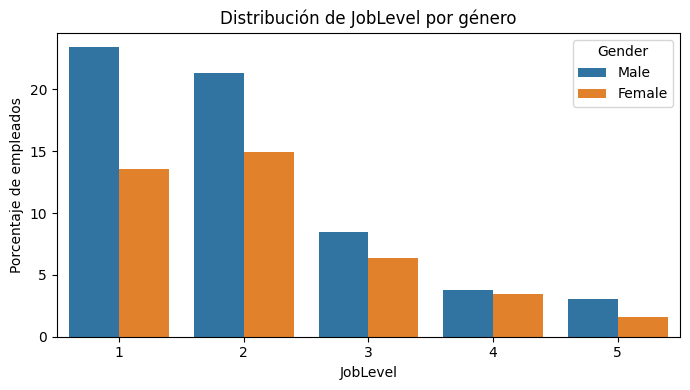

In [18]:
plt.figure(figsize=(7,4))
sns.countplot(
    data=df,
    x='JobLevel',
    hue='Gender',
    stat='percent'  # si tu versión de seaborn no lo soporta, quita este argumento
)
plt.title('Distribución de JobLevel por género')
plt.xlabel('JobLevel')
plt.ylabel('Porcentaje de empleados')
plt.tight_layout()
plt.show()


In [19]:
salario_genero_nivel_rol = df.groupby(['JobLevel','JobRole','Gender'])['MonthlyIncome'].mean()
print(salario_genero_nivel_rol)


JobLevel  JobRole                    Gender
1         Human Resources            Female     2653.000000
                                     Male       2768.086957
          Laboratory Technician      Female     2821.208955
                                     Male       2871.406015
          Research Scientist         Female     2869.873563
                                     Male       2833.333333
          Sales Representative       Female     2628.600000
                                     Male       2498.146341
2         Healthcare Representative  Female     5727.741935
                                     Male       5818.085106
          Human Resources            Female     5859.333333
                                     Male       5516.400000
          Laboratory Technician      Female     4680.176471
                                     Male       4334.589744
          Manufacturing Director     Female     5257.390244
                                     Male       5908.142

Lectura clave por niveles
Nivel 1
Diferencias muy pequeñas entre hombres y mujeres en todos los roles.
En algunos (Research Scientist, Sales Representative) las mujeres incluso cobran ligeramente más; en otros (HR, Lab Technician) los hombres.
​
Nivel 2
En Healthcare Representative y Manufacturing Director los hombres cobran algo más.
En Human Resources, Laboratory Technician y Sales Representative las mujeres ganan más.
En Research Scientist y Sales Executive las diferencias son pequeñas.
​
Nivel 3
En Healthcare Representative y Manufacturing Director los hombres tienen salarios algo superiores.
En Human Resources, Laboratory Technician y Manager las mujeres cobran más.
En Research Director y Sales Executive las diferencias son mínimas; en Research Scientist solo hay hombres en este nivel.
​
Nivel 4
En Healthcare Representative y Manufacturing Director los resultados están mezclados (a veces mejor las mujeres, a veces los hombres).
En Manager y Research Director los salarios son prácticamente iguales entre géneros.
En Sales Executive las diferencias son marginales.
​
Nivel 5
En Manager y Research Director los hombres cobran algo más de media, pero la distancia no es enorme

Al comparar la retribución por género dentro del mismo nivel jerárquico (JobLevel) y rol (JobRole), no se observa una brecha salarial sistemática a favor de un único género. En los niveles más bajos (JobLevel 1–2) las diferencias entre hombres y mujeres son pequeñas y, según el rol, pueden favorecer tanto a unas como a otros. En los niveles intermedios y altos (JobLevel 3–5) se repite este patrón mixto: en algunos puestos los hombres presentan salarios medios algo superiores, mientras que en otros ocurre lo contrario. En conjunto, esto sugiere que, en este dataset, las diferencias salariales parecen más vinculadas al tipo de rol y al nivel que a una discriminación directa por género dentro de la misma posición, aunque sigue siendo importante vigilar casos concretos donde las distancias sean mayores.

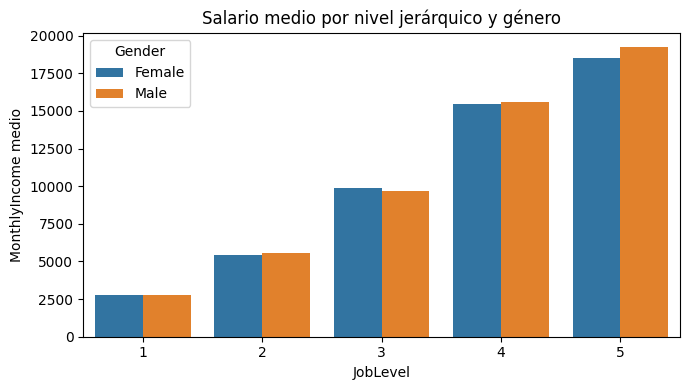

In [20]:
# Salario medio por JobLevel y género
salario_genero_nivel = (
    df.groupby(['JobLevel','Gender'])['MonthlyIncome']
      .mean()
      .reset_index()
)

plt.figure(figsize=(7,4))
sns.barplot(
    data=salario_genero_nivel,
    x='JobLevel',
    y='MonthlyIncome',
    hue='Gender'
)
plt.title('Salario medio por nivel jerárquico y género')
plt.xlabel('JobLevel')
plt.ylabel('MonthlyIncome medio')
plt.tight_layout()
plt.show()


## OTROS CRUCES DE VARIABLES RELACIONADOS CON EDAD, DISTANCIA, CARGA DE TRABAJO...

In [21]:
# Rotación por grupo de edad
rotacion_age = df.groupby('AgeGroup')['Attrition_flag'].mean().sort_index()
print("Rotación por grupo de edad:\n", rotacion_age, "\n")

# Satisfacción por grupo de edad
satisf_age = df.groupby('AgeGroup')['JobSatisfaction'].mean().sort_index()
print("JobSatisfaction media por grupo de edad:\n", satisf_age, "\n")

# Rotación por edad y departamento
rotacion_age_depto = df.groupby(['AgeGroup','Department'])['Attrition_flag'].mean()
print("Rotación por grupo de edad y departamento:\n", rotacion_age_depto, "\n")


Rotación por grupo de edad:
 AgeGroup
30-40    0.145427
40-50    0.095808
<30      0.280130
>=50     0.135802
Name: Attrition_flag, dtype: float64 

JobSatisfaction media por grupo de edad:
 AgeGroup
30-40    2.784108
40-50    2.646707
<30      2.745928
>=50     2.716049
Name: JobSatisfaction, dtype: float64 

Rotación por grupo de edad y departamento:
 AgeGroup  Department            
30-40     Human Resources           0.185185
          Research & Development    0.117359
          Sales                     0.175926
          Unknown                   0.400000
40-50     Human Resources           0.062500
          Research & Development    0.064516
          Sales                     0.157895
          Unknown                   0.333333
<30       Human Resources           0.461538
          Research & Development    0.254902
          Sales                     0.306818
          Unknown                   0.500000
>=50      Human Resources           0.000000
          Research & Devel

Impacto de la edad en la rotación
La rotación no afecta por igual a todos los grupos de edad. El colectivo con mayor fuga de talento es claramente el de menores de 30 años, con una tasa de rotación del 28,0%, muy por encima de la media global (16,1%). En el tramo de 30‑40 años la rotación desciende al 14,5%, cae todavía más en el grupo de 40‑50 años (9,6%) y vuelve a subir ligeramente en mayores de 50 (13,6%). Estos datos confirman que la empresa tiene un problema específico de retención de talento joven, mientras que los perfiles de más experiencia tienden a ser más estables.
Satisfacción laboral por edad
La satisfacción media en el trabajo (JobSatisfaction) se mantiene relativamente estable entre grupos de edad, con valores cercanos a 2,7–2,8 sobre 4. Los empleados de 30‑40 años declaran la mayor satisfacción media (2,78), seguidos de los menores de 30 (2,75) y los mayores de 50 (2,72), mientras que el grupo de 40‑50 años presenta la puntuación ligeramente más baja (2,65). Esto sugiere que la alta rotación de los más jóvenes no se explica solo por una insatisfacción extrema, sino también por factores propios de la etapa de carrera (movilidad, búsqueda de mejores oportunidades, etc.).
Edad, departamento y fuga de talento
Al cruzar edad y departamento, el patrón se refuerza: entre los menores de 30 años, la rotación supera el 25% en Research & Development y alcanza un 30,7% en Sales y un 46,2% en Human Resources, con un preocupante 50% en el grupo de departamento Unknown. A medida que aumenta la edad, estas tasas se moderan: en el tramo 40‑50 la rotación llega a ser tan baja como el 6,3% en Human Resources y el 6,5% en R&D, aunque se mantiene algo más alta en Sales. En resumen, la combinación de juventud y determinados entornos (Sales, R&D y funciones de soporte mal definidas) actúa como un multiplicador del riesgo de salida.

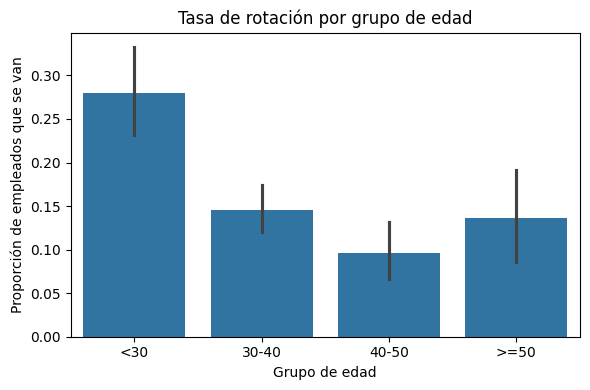

In [22]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x='AgeGroup',
    y='Attrition_flag',
    estimator='mean',
    order=['<30','30-40','40-50','>=50']
)
plt.title('Tasa de rotación por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Proporción de empleados que se van')
plt.tight_layout()
plt.show()


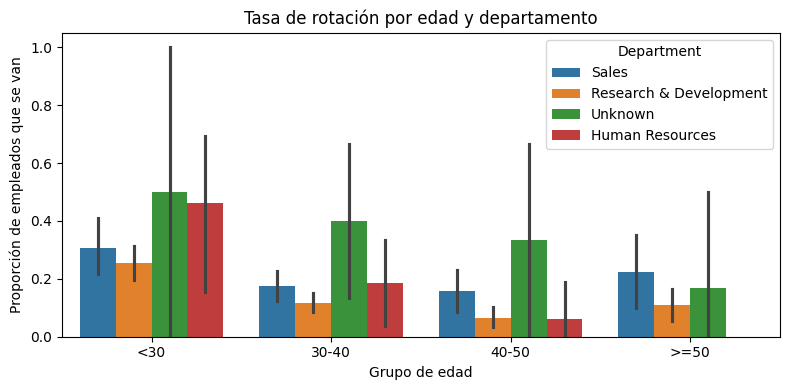

In [23]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=df,
    x='AgeGroup',
    y='Attrition_flag',
    hue='Department',
    estimator='mean',
    order=['<30','30-40','40-50','>=50']
)
plt.title('Tasa de rotación por edad y departamento')
plt.xlabel('Grupo de edad')
plt.ylabel('Proporción de empleados que se van')
plt.tight_layout()
plt.show()


In [25]:
# Crear tramos de distancia
bins = [0, 5, 10, 20, 100]
labels = ['0-5', '5-10', '10-20', '>=20']
df['DistanceBand'] = pd.cut(df['DistanceFromHome'], bins=bins, labels=labels, right=False)

# Rotación por tramo de distancia
rotacion_dist = df.groupby('DistanceBand')['Attrition_flag'].mean().sort_index()
print("Rotación por tramo de distancia:\n", rotacion_dist, "\n")

# Rotación por distancia y OverTime
rotacion_dist_overtime = df.groupby(['DistanceBand','OverTime'])['Attrition_flag'].mean()
print("Rotación por distancia y OverTime:\n", rotacion_dist_overtime, "\n")

# WorkLifeBalance medio por tramo de distancia
wlb_dist = df.groupby('DistanceBand')['WorkLifeBalance'].mean().sort_index()
print("WorkLifeBalance medio por distancia:\n", wlb_dist, "\n")


Rotación por tramo de distancia:
 DistanceBand
0-5      0.135802
5-10     0.150134
10-20    0.182724
>=20     0.213974
Name: Attrition_flag, dtype: float64 

Rotación por distancia y OverTime:
 DistanceBand  OverTime
0-5           No          0.083744
              Unknown     0.266667
              Yes         0.267123
5-10          No          0.103053
              Unknown     0.076923
              Yes         0.285714
10-20         No          0.121827
              Unknown     0.100000
              Yes         0.319149
>=20          No          0.121795
              Unknown     0.333333
              Yes         0.417910
Name: Attrition_flag, dtype: float64 

WorkLifeBalance medio por distancia:
 DistanceBand
0-5      2.788360
5-10     2.739946
10-20    2.757475
>=20     2.733624
Name: WorkLifeBalance, dtype: float64 



C:\Users\PC\AppData\Local\Temp\ipykernel_20036\38644871.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rotacion_dist = df.groupby('DistanceBand')['Attrition_flag'].mean().sort_index()
C:\Users\PC\AppData\Local\Temp\ipykernel_20036\38644871.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rotacion_dist_overtime = df.groupby(['DistanceBand','OverTime'])['Attrition_flag'].mean()
C:\Users\PC\AppData\Local\Temp\ipykernel_20036\38644871.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior 

Impacto de la distancia en la rotación
La probabilidad de abandono aumenta de forma progresiva con la distancia al trabajo. Los empleados que viven a menos de 5 km presentan una tasa de rotación del 13,6%, que sube al 15,0% en el tramo 5‑10 km, al 18,3% entre 10‑20 km y alcanza el 21,4% cuando la distancia es igual o superior a 20 km. Es decir, los empleados más alejados del centro de trabajo rotan alrededor de un 60% más que los que viven a menos de 5 km.
Distancia, horas extra y riesgo de salida
Al cruzar distancia y OverTime, el efecto se intensifica. Entre quienes no hacen horas extra, la rotación se mantiene relativamente contenida y bastante estable en todos los tramos (en torno al 8–12%). Sin embargo, cuando hay horas extra, la rotación se dispara: alrededor del 26–29% para quienes viven a menos de 10 km, 31,9% en el tramo 10‑20 km y hasta un 41,8% en los empleados que viven a 20 km o más. Esto indica que la combinación “mucha distancia + overtime” es uno de los focos de riesgo más altos de toda la organización.
Balance vida‑trabajo por distancia
El WorkLifeBalance medio se mantiene bastante similar entre tramos de distancia (entre 2,73 y 2,79 sobre 4), sin degradarse de forma drástica en los empleados que viven más lejos. Esto sugiere que la distancia impacta más directamente en la decisión de rotar (probablemente por tiempo y coste de desplazamiento) que en la percepción declarada del equilibrio vida‑trabajo.

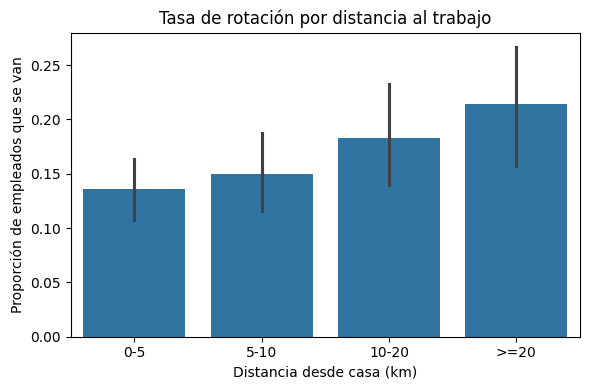

In [26]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x='DistanceBand',
    y='Attrition_flag',
    estimator='mean',
    order=['0-5','5-10','10-20','>=20']
)
plt.title('Tasa de rotación por distancia al trabajo')
plt.xlabel('Distancia desde casa (km)')
plt.ylabel('Proporción de empleados que se van')
plt.tight_layout()
plt.show()


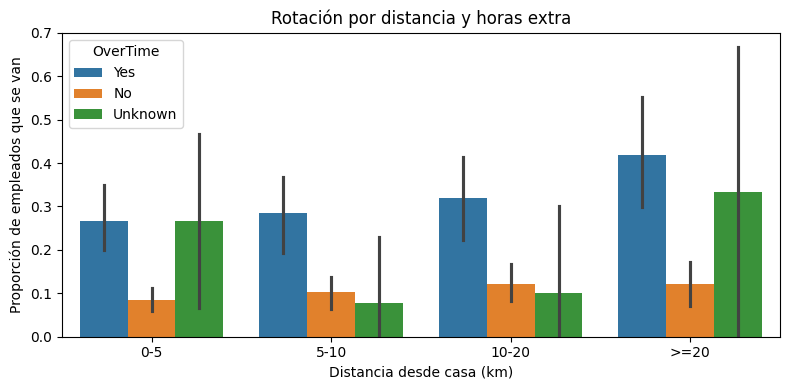

In [27]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=df,
    x='DistanceBand',
    y='Attrition_flag',
    hue='OverTime',
    estimator='mean',
    order=['0-5','5-10','10-20','>=20']
)
plt.title('Rotación por distancia y horas extra')
plt.xlabel('Distancia desde casa (km)')
plt.ylabel('Proporción de empleados que se van')
plt.tight_layout()
plt.show()


In [28]:
segmentos = (
    df.groupby(['AgeGroup', 'DistanceBand', 'OverTime'])['Attrition_flag']
      .mean()
      .reset_index()
)

print(segmentos.sort_values('Attrition_flag', ascending=False).head(15))


   AgeGroup DistanceBand OverTime  Attrition_flag
25      <30          0-5  Unknown        0.750000
35      <30         >=20      Yes        0.636364
32      <30        10-20      Yes        0.565217
29      <30         5-10      Yes        0.560000
26      <30          0-5      Yes        0.466667
11    30-40         >=20      Yes        0.448276
23    40-50         >=20      Yes        0.375000
38     >=50          0-5      Yes        0.333333
22    40-50         >=20  Unknown        0.333333
10    30-40         >=20  Unknown        0.333333
44     >=50        10-20      Yes        0.333333
5     30-40         5-10      Yes        0.277778
33      <30         >=20       No        0.270270
8     30-40        10-20      Yes        0.234043
20    40-50        10-20      Yes        0.222222


C:\Users\PC\AppData\Local\Temp\ipykernel_20036\3996071170.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['AgeGroup', 'DistanceBand', 'OverTime'])['Attrition_flag']


Segmentos críticos de fuga de talento
El riesgo máximo se concentra en empleados menores de 30 años que combinan distancia elevada y horas extra. En este grupo, la probabilidad de abandono supera el 56% cuando viven a más de 10 km (56–64% en tramos 10‑20 km y ≥20 km) y se mantiene muy alta incluso con distancias cortas si hacen horas extra (por ejemplo, 46,7% con menos de 5 km). Además, aparece un grupo extremo con <30 años, muy cercano al trabajo pero con OverTime = Unknown, cuya rotación alcanza el 75%, lo que sugiere situaciones contractuales o de registro de jornada poco claras.

Efecto de la distancia en adultos y seniors
La combinación “≥20 km + OverTime = Yes” mantiene tasas de rotación muy elevadas en todos los tramos de edad: 44,8% para 30‑40 años, 37,5% para 40‑50 años y 33,3% en mayores de 50. Esto confirma que el impacto del desplazamiento largo se vuelve especialmente problemático cuando se suma a jornadas ampliadas, incluso en perfiles con más antigüedad y, en principio, mayor estabilidad.


Segmentos de comparación (riesgo medio)
Sirven como contraste los segmentos con overtime pero menor distancia: por ejemplo, 30‑40 años con 5‑10 km y horas extra presentan un riesgo moderado (alrededor del 27,8%), claramente inferior al de quienes hacen horas extra y viven a ≥20 km. Igualmente, los empleados jóvenes <30 que viven lejos (≥20 km) pero no realizan overtime muestran un riesgo intermedio (27,0%), lo que refuerza la idea de que la palanca más peligrosa es la combinación simultánea de juventud, larga distancia y horas extra.

C:\Users\PC\AppData\Local\Temp\ipykernel_20036\3112240281.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['AgeGroup', 'DistanceBand', 'OverTime'])['Attrition_flag']


<Figure size 1000x500 with 0 Axes>

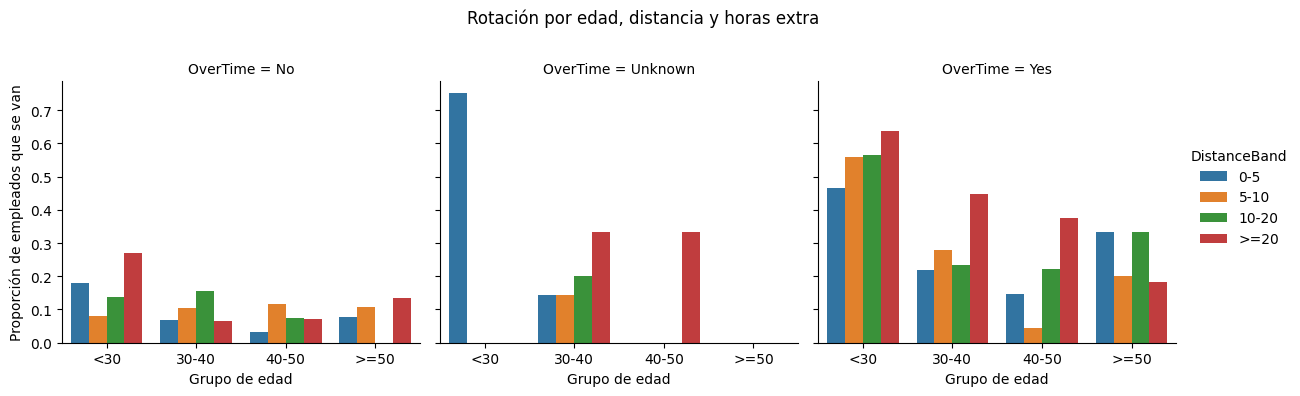

In [30]:
plt.figure(figsize=(10, 5))

segmentos_plot = (
    df.groupby(['AgeGroup', 'DistanceBand', 'OverTime'])['Attrition_flag']
      .mean()
      .reset_index()
)

g = sns.catplot(
    data=segmentos_plot,
    kind='bar',
    x='AgeGroup',
    y='Attrition_flag',
    hue='DistanceBand',
    col='OverTime',
    order=['<30','30-40','40-50','>=50'],
    hue_order=['0-5','5-10','10-20','>=20'],
    height=4,
    aspect=1
)

g.set_axis_labels("Grupo de edad", "Proporción de empleados que se van")
g.set_titles("OverTime = {col_name}")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Rotación por edad, distancia y horas extra')
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_20036\3993959677.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['AgeGroup','DistanceBand'])['Attrition_flag']


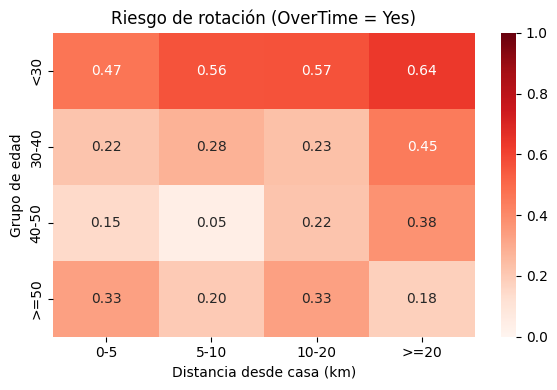

In [31]:
# Filtramos solo los que tienen OverTime = 'Yes'
df_yes = df[df['OverTime'] == 'Yes']

pivot_yes = (
    df_yes
    .groupby(['AgeGroup','DistanceBand'])['Attrition_flag']
    .mean()
    .reset_index()
    .pivot(index='AgeGroup', columns='DistanceBand', values='Attrition_flag')
    .loc[['<30','30-40','40-50','>=50'], ['0-5','5-10','10-20','>=20']]
)

plt.figure(figsize=(6,4))
sns.heatmap(
    pivot_yes,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=1
)
plt.title('Riesgo de rotación (OverTime = Yes)')
plt.xlabel('Distancia desde casa (km)')
plt.ylabel('Grupo de edad')
plt.tight_layout()
plt.show()


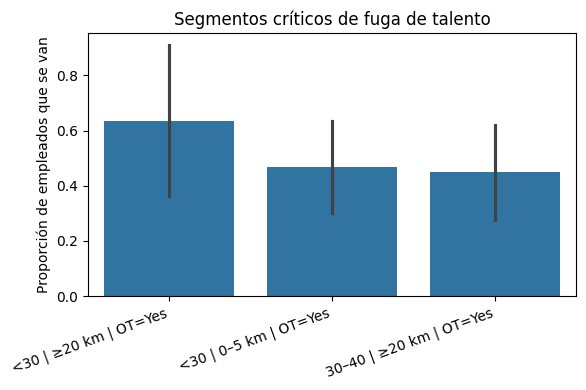

In [32]:
segmentos_clave = [
    ('<30', '>=20', 'Yes'),
    ('<30', '0-5', 'Yes'),
    ('30-40', '>=20', 'Yes'),
]

mask = df.set_index(['AgeGroup','DistanceBand','OverTime']).index.isin(segmentos_clave)
df_segmentos = df[mask].copy()

segmento_labels = {
    ('<30', '>=20', 'Yes'): '<30 | ≥20 km | OT=Yes',
    ('<30', '0-5', 'Yes'):  '<30 | 0–5 km | OT=Yes',
    ('30-40', '>=20', 'Yes'): '30–40 | ≥20 km | OT=Yes',
}

df_segmentos['Segmento'] = list(
    map(segmento_labels.get,
        df_segmentos.set_index(['AgeGroup','DistanceBand','OverTime']).index)
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=df_segmentos,
    x='Segmento',
    y='Attrition_flag',
    estimator='mean'
)
plt.title('Segmentos críticos de fuga de talento')
plt.xlabel('')
plt.ylabel('Proporción de empleados que se van')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
